In [10]:
!pip install xlrd openpyxl

Lecture des fichiers Excels (merci de bien vouloir patienter...)


C:\Users\tarek\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Génération de la Loi de Zipf...


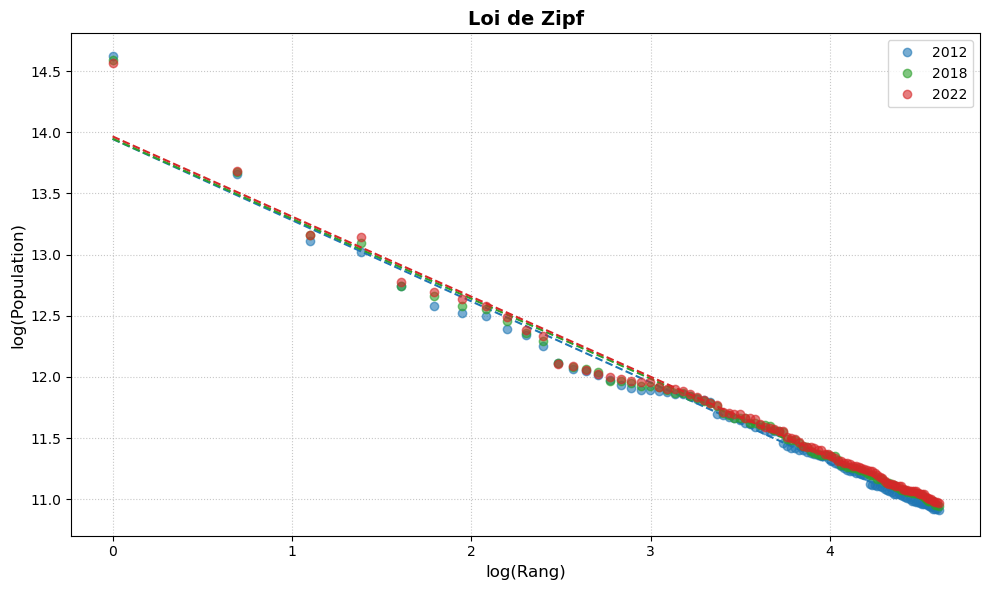

Génération de la Loi de Gibrat...


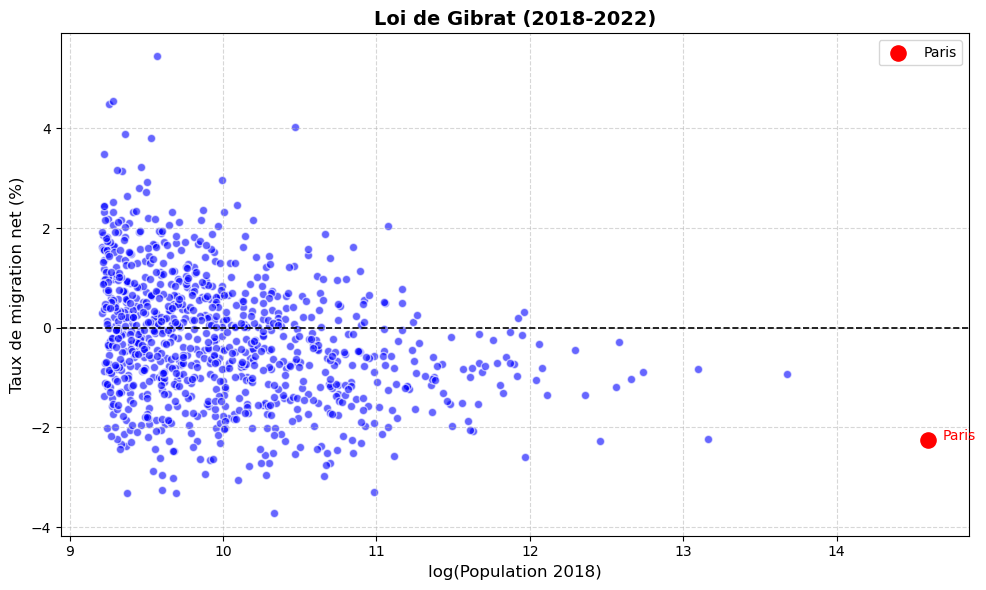

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../outputs', exist_ok=True)
print("Lecture des fichiers Excels (merci de bien vouloir patienter...)")

def preparer_population(fichier, annee):
    df = pd.read_excel(fichier, sheet_name='Communes', header=7, dtype={'Code département': str, 'Code commune': str})
    df['code'] = df['Code département'] + df['Code commune']
    #les colonnes qui nous intéressent :
    df_clean = df[['code', 'Nom de la commune', 'Population municipale']].copy()
    df_clean.columns = ['code', 'nom', f'pop_{annee}']
    return df_clean

pop_12 = preparer_population('../inputs/ensemble2012.xls', '2012')
pop_18 = preparer_population('../inputs/ensemble2018.xlsx', '2018')
pop_22 = preparer_population('../inputs/ensemble2022.xlsx', '2022')
df_pop = pd.merge(pop_12, pop_18[['code', 'pop_2018']], on='code', how='outer')
df_pop = pd.merge(df_pop, pop_22[['code', 'pop_2022']], on='code', how='outer')

def regrouper_arrondissements(code):
    code = str(code)
    if code.startswith('751'): return 'Paris'
    if code.startswith('6938'): return 'Lyon'
    if code.startswith('132'): return 'Marseille'
    return code

df_pop['code_regroupe'] = df_pop['code'].apply(regrouper_arrondissements)

#taille totale des métropoles
pop_finale = df_pop.groupby('code_regroupe')[['pop_2012', 'pop_2018', 'pop_2022']].sum().reset_index()

#Loi de zipf
print("Génération de la Loi de Zipf...")
plt.figure(figsize=(10, 6))

annees_zipf = ['pop_2012', 'pop_2018', 'pop_2022']
couleurs = ['#1f77b4', '#2ca02c', '#d62728'] #bleu, vert, rouge
labels = ['2012', '2018', '2022']

for annee, couleur, label in zip(annees_zipf, couleurs, labels):
    df_zipf = pop_finale.sort_values(annee, ascending=False).head(100).copy() #top 100
    df_zipf = df_zipf[df_zipf[annee] > 0].copy() 
    df_zipf['rang'] = np.arange(1, len(df_zipf) + 1)
    ln_pop = np.log(df_zipf[annee]) #echelle logarithmique
    ln_rang = np.log(df_zipf['rang'])
    plt.plot(ln_rang, ln_pop, marker='o', linestyle='', color=couleur, alpha=0.6, label=label)
    z = np.polyfit(ln_rang, ln_pop, 1)
    p = np.poly1d(z)
    plt.plot(ln_rang, p(ln_rang), color=couleur, linestyle='--', linewidth=1.5)

plt.title("Loi de Zipf", fontsize=14, fontweight='bold')
plt.xlabel("log(Rang)", fontsize=12)
plt.ylabel("log(Population)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/Loi_de_Zipf.png', dpi=300)
plt.show()

#Loi de Gibrat
print("Génération de la Loi de Gibrat...")
df_flux = pd.read_csv('../outputs/flux_migratoire_triee.csv', sep=';', dtype=str)
df_flux['flux'] = df_flux['flux'].astype(float)
df_flux_2022 = df_flux[df_flux['annee'] == '2022'].copy()
df_flux_2022['ville_orig'] = df_flux_2022['code_orig'].apply(regrouper_arrondissements)
df_flux_2022['ville_dest'] = df_flux_2022['code_dest'].apply(regrouper_arrondissements)
entrees = df_flux_2022.groupby('ville_dest')['flux'].sum().reset_index().rename(columns={'ville_dest': 'code_regroupe', 'flux': 'entrees'})
sorties = df_flux_2022.groupby('ville_orig')['flux'].sum().reset_index().rename(columns={'ville_orig': 'code_regroupe', 'flux': 'sorties'})

#solde migratoire 2022
bilan = pd.merge(entrees, sorties, on='code_regroupe', how='outer').fillna(0)
bilan['solde_migratoire'] = bilan['entrees'] - bilan['sorties']
df_gibrat = pd.merge(bilan, pop_finale, on='code_regroupe', how='inner')

df_gibrat_plot = df_gibrat[df_gibrat['pop_2018'] > 10000].copy() # on garde les villes > 10 000
df_gibrat_plot['log_pop_2018'] = np.log(df_gibrat_plot['pop_2018'])

#calcul taux de migration net (nous n'avons pris en compte que les flux migratoires, et nous n'avons pas inclus les naissances et décès qui auraient pu biaiser nos résultats).
df_gibrat_plot['taux_migration_net'] = (df_gibrat_plot['solde_migratoire'] / df_gibrat_plot['pop_2018']) * 100

plt.figure(figsize=(10, 6))
plt.scatter(df_gibrat_plot['log_pop_2018'], df_gibrat_plot['taux_migration_net'], alpha=0.6, color='blue', edgecolors='white')
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')

#exemple Paris
paris_data = df_gibrat_plot[df_gibrat_plot['code_regroupe'] == 'Paris']
if not paris_data.empty:
    plt.scatter(paris_data['log_pop_2018'], paris_data['taux_migration_net'], color='red', s=120, label="Paris", zorder=5)
    plt.annotate("Paris", (paris_data['log_pop_2018'].values[0] + 0.1, paris_data['taux_migration_net'].values[0]), color='red')

plt.title("Loi de Gibrat (2018-2022)", fontsize=14, fontweight='bold')
plt.xlabel("log(Population 2018)", fontsize=12)
plt.ylabel("Taux de migration net (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
if not paris_data.empty: plt.legend()
plt.tight_layout()
plt.savefig('../outputs/Loi_de_Gibrat.png', dpi=300)
plt.show()